#### =========================
### 1. IMPORT LIBRARIES
#### =========================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
import pickle
import gradio as gr


#### =========================
### 2. LOAD DATASET
#### =========================

In [4]:
df = pd.read_csv(r"Stress Level Dataset.csv")

df.head()

,Age,Gender,Sleep Duration,Quality of Sleep,Physical Activity Level,Work Hours,Screen Time,Stress Level
0,56,Male,6.44,Good,Moderate,9.10,10.00,Medium
1,46,Male,7.01,Good,Moderate,8.37,6.81,Medium
2,32,Female,6.43,Good,Low,8.43,7.64,Medium
3,25,Male,7.24,Good,High,7.88,7.72,Low
4,38,Female,8.17,Good,High,6.43,6.10,Low


#### =========================
### 3. DATA CLEANING
#### =========================

In [6]:
df.isnull().sum()

Age                        0
Gender                     0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Work Hours                 0
Screen Time                0
Stress Level               0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      25000 non-null  int64  
 1   Gender                   25000 non-null  object 
 2   Sleep Duration           25000 non-null  float64
 3   Quality of Sleep         25000 non-null  object 
 4   Physical Activity Level  25000 non-null  object 
 5   Work Hours               25000 non-null  float64
 6   Screen Time              25000 non-null  float64
 7   Stress Level             25000 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 1.7+ MB


In [5]:
df.describe()

,Age,Sleep Duration,Work Hours,Screen Time
count,25450.000000,25450.000000,25450.000000,25450.000000
mean,38.447151,6.498975,8.497251,7.818966
std,12.054742,1.163080,1.650829,1.677079
min,18.000000,4.000000,4.000000,2.000000
25%,28.000000,5.680000,7.360000,6.670000
50%,38.000000,6.500000,8.510000,7.960000
75%,49.000000,7.320000,9.660000,9.240000
max,59.000000,9.000000,12.000000,10.000000


In [6]:
df.drop_duplicates(inplace=True)
df.fillna(method='ffill', inplace=True)

#### =========================
### 4. DATA DISTRIBUTION (SUBPLOTS)
#### =========================

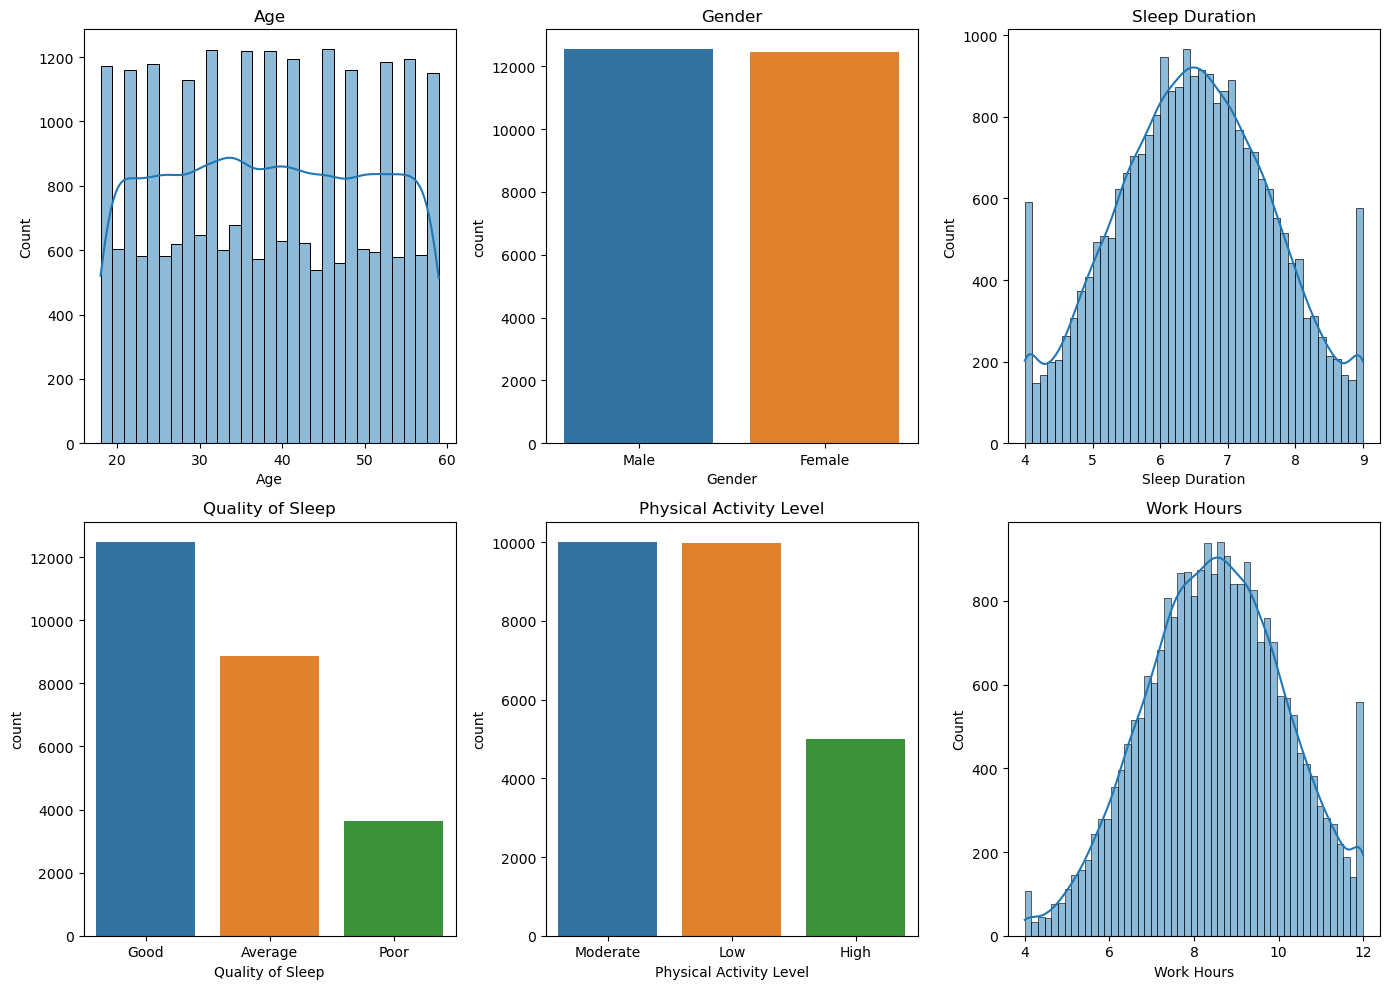

In [7]:
plt.figure(figsize=(14,10))

for i, col in enumerate(df.columns[:6]):
    plt.subplot(2,3,i+1)
    
    if df[col].dtype == 'object':
        sns.countplot(x=col, data=df)
    else:
        sns.histplot(df[col], kde=True)
        
    plt.title(f"{col}")

plt.tight_layout()
plt.show()

#### =========================
### 5. FEATURE / TARGET SPLIT
#### =========================

In [8]:
target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

#### =========================
### 6. STORE CATEGORICAL INFO
#### =========================

In [9]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

category_values = {}
for col in cat_cols:
    category_values[col] = X[col].unique().tolist()

#### =========================
### 7. ENCODING
#### =========================

In [10]:
encoders = {}

for col in cat_cols:
    le_col = LabelEncoder()
    X[col] = le_col.fit_transform(X[col])
    encoders[col] = le_col

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(y)

#### =========================
### 8. SCALING (ONLY NUMERICAL)
#### =========================

In [11]:
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

#### =========================
### 9. TRAIN TEST SPLIT
#### =========================

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### =========================
### 10. CHECK IMBALANCE + SMOTE
#### =========================

In [13]:
print("Class Distribution:", np.bincount(y_train))

if min(np.bincount(y_train)) / max(np.bincount(y_train)) < 0.6:
    print("⚠️ Applying SMOTE...")
    sm = SMOTE(random_state=42)
    X_train, y_train = sm.fit_resample(X_train, y_train)

Class Distribution: [6666 6667 6667]


#### =========================
### 11. MODEL TRAINING
#### =========================

#### ✅ 1. Logistic Regression

In [14]:
# Logistic Regression
lr_model = LogisticRegression()

# Train
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Accuracy
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 69.78%


#### 🌳 2. Random Forest

In [15]:
# Random Forest
rf_model = RandomForestClassifier()

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Random Forest Accuracy: 73.06%


#### 🚀 3. Gradient Boosting

In [16]:
# Gradient Boosting
gb_model = GradientBoostingClassifier()

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Accuracy
gb_acc = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Accuracy: {gb_acc*100:.2f}%")

Gradient Boosting Accuracy: 74.16%


#### ⚡ 4. Support Vector Machine(SVM)

In [ ]:
# SVM
svm_model = SVC()

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {svm_acc*100:.2f}%")

### All Accuracies

In [23]:
accuracies = {
    "Logistic Regression": lr_acc,
    "Random Forest": rf_acc,
    "Gradient Boosting": gb_acc,
    "SVM": svm_acc
}

# Print all results
for model, acc in accuracies.items():
    print(f"{model}: {acc*100:.2f}%")

Logistic Regression: 69.78%
Random Forest: 73.20%
Gradient Boosting: 74.16%
SVM: 74.02%


#### =========================
### 12. MODEL COMPARISON GRAPH
#### =========================

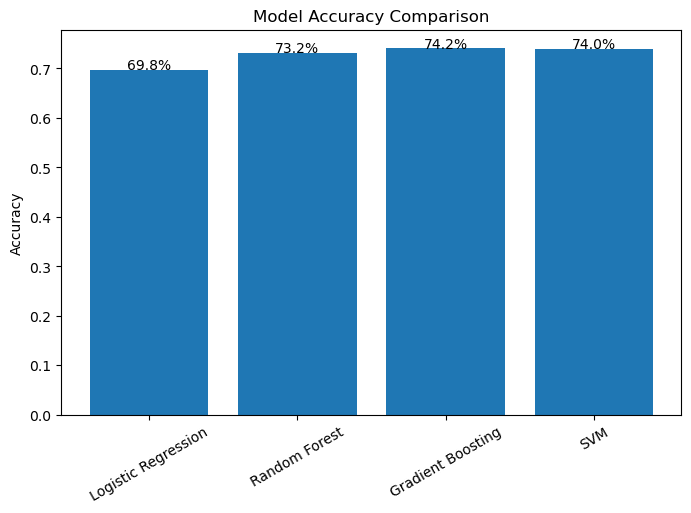

In [24]:
plt.figure(figsize=(8,5))
bars = plt.bar(accuracies.keys(), accuracies.values())

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height()*100:.1f}%",
             ha='center')

plt.show()

#### =========================
### 13. CONFUSION MATRICES
#### =========================

In [27]:
trained_models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "SVM": svm_model
}

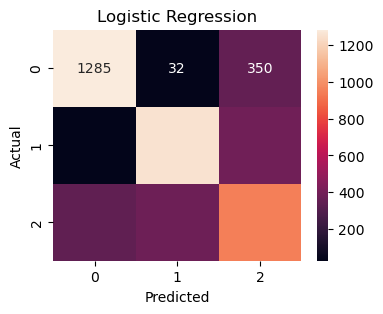

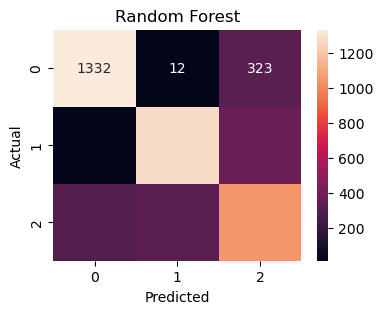

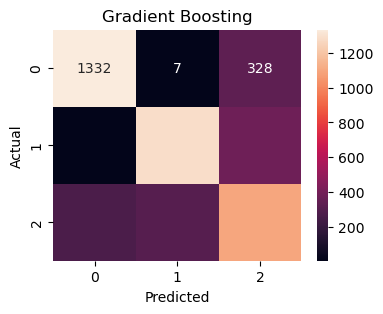

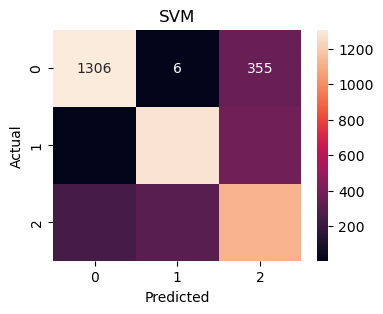

In [28]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

#### =========================
### 14. BEST MODEL
#### =========================

In [31]:
best_model_name = max(accuracies, key=accuracies.get)
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


#### =========================
### 15. SAVE MODEL
#### =========================

In [3]:
pickle.dump(best_model, open("best_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))

NameError: name 'best_model' is not defined

#### =========================
### 16. GRADIO DEPLOYMENT
#### =========================

In [33]:
model = pickle.load(open("best_model.pkl","rb"))
scaler = pickle.load(open("scaler.pkl","rb"))

feature_names = X.columns

def predict(*inputs):
    input_dict = dict(zip(feature_names, inputs))
    input_df = pd.DataFrame([input_dict])

    # Encode categorical
    for col in cat_cols:
        input_df[col] = encoders[col].transform([input_df[col][0]])

    # Scale numerical
    input_df[num_cols] = scaler.transform(input_df[num_cols])

    pred = model.predict(input_df)[0]

    return le_target.inverse_transform([pred])[0]

#### =========================
### CREATE UI (FINAL FIXED)
#### =========================

In [34]:
inputs = []

for col in feature_names:
    
    if col in cat_cols:
        # Dropdown for categorical
        inputs.append(
            gr.Dropdown(
                choices=category_values[col],
                label=col
            )
        )
    
    else:
        # Special case: Age → INTEGER slider
        if col.lower() == "age":
            inputs.append(
                gr.Slider(
                    minimum=int(df[col].min()),
                    maximum=int(df[col].max()),
                    step=1,   # ✅ integer step
                    label=col
                )
            )
        else:
            # Other numerical → decimal slider
            inputs.append(
                gr.Slider(
                    minimum=float(df[col].min()),
                    maximum=float(df[col].max()),
                    step=0.1,
                    label=col
                )
            )

In [35]:
app = gr.Interface(
    fn=predict,
    inputs=inputs,
    outputs=gr.Textbox(label="Predicted Stress Level"),
    title="Stress Level Predictor"
)

app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
